# Continuous Systems

Let's think about simulating continuous systems. A continuous system is one that changes continuously over time, as opposed to discrete systems which change at specific intervals.

## Chemical Reaction Simulation

This simulation models a reversible chemical reaction where compounds A and B react to form C. The system is governed by the following differential equations:

$$\frac{d[A]}{dt} = -k_1[A][B] + k_2[C]$$

$$\frac{d[B]}{dt} = -k_1[A][B] + k_2[C]$$

$$\frac{d[C]}{dt} = 2(k_1[A][B] - k_2[C])$$

Then let's try the **Forward Euler Method**, which is a first-order numerical procedure for solving ODEs. It approximates the derivative by using a small time step ($\Delta t$):

$$[X]_{t+\Delta t} \approx [X]_t + \left( \frac{d[X]}{dt} \right) \Delta t$$


Where:
- $k_1 = 0.025$ is the forward reaction rate constant
- $k_2 = 0.01$ is the reverse reaction rate constant
- $[A]$, $[B]$, and $[C]$ represent the concentrations of compounds A, B, and C respectively

The simulation uses Euler's method with a time step of $\Delta t = 0.1$ to numerically integrate these equations over 15 time units, starting with initial concentrations $[A]_0 = 50.0$, $[B]_0 = 25.0$, and $[C]_0 = 0.0$.

Time	[A]	[B]	[C]
0.00	50.0000	25.0000	0.0000
0.10	46.8750	21.8750	6.2500
0.20	44.3178	19.3178	11.3645
0.30	42.1888	17.1888	15.6223
0.40	40.3915	15.3915	19.2170
0.50	38.8565	13.8565	22.2870
0.60	37.5328	12.5328	24.9345
0.70	36.3817	11.3817	27.2366
0.80	35.3737	10.3737	29.2525
0.90	34.4856	9.4856	31.0288
1.00	33.6988	8.6988	32.6023
1.10	32.9986	7.9986	34.0028
1.20	32.3727	7.3727	35.2545
1.30	31.8113	6.8113	36.3774
1.40	31.3060	6.3060	37.3880
1.50	30.8498	5.8498	38.3003
1.60	30.4370	5.4370	39.1261
1.70	30.0624	5.0624	39.8752
1.80	29.7218	4.7218	40.5564
1.90	29.4115	4.4115	41.1770
2.00	29.1283	4.1283	41.7434
2.10	28.8694	3.8694	42.2612
2.20	28.6324	3.6324	42.7352
2.30	28.4151	3.4151	43.1697
2.40	28.2157	3.2157	43.5686
2.50	28.0324	3.0324	43.9351
2.60	27.8639	2.8639	44.2723
2.70	27.7086	2.7086	44.5827
2.80	27.5656	2.5656	44.8688
2.90	27.4336	2.4336	45.1327
3.00	27.3119	2.3119	45.3763
3.10	27.1994	2.1994	45.6012
3.20	27.0954	2.0954	45.8091
3.30	26.9993	1.9993	46.0014
3.40	26.9104	1.9104	46.1

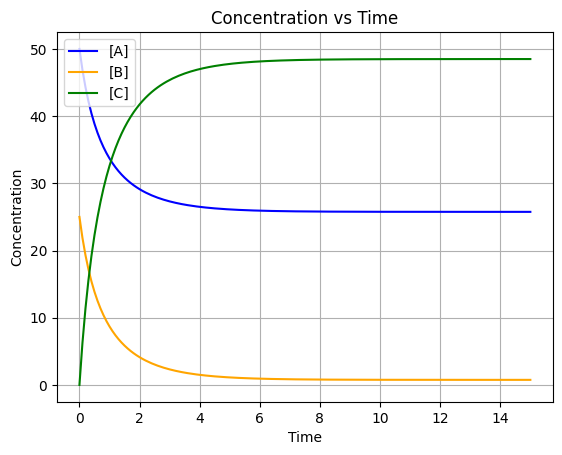

In [5]:
import matplotlib.pyplot as plt

class ChemicalReaction:
    def __init__(self, k1, k2, c1, c2, c3, time_diff=0.1):
        self.k1 = k1  # Rate constant for forward reaction
        self.k2 = k2  # Rate constant for reverse reaction
        self.c1 = c1  # Initial concentration of A
        self.c2 = c2  # Initial concentration of B
        self.c3 = c3  # Initial concentration of C
        self.time_diff = time_diff  # Time step for simulation

        self.time_points = [0]
        self.concentration_A = [c1]
        self.concentration_B = [c2]
        self.concentration_C = [c3]

    def simulate_reaction(self, total_time):
        steps = int(total_time / self.time_diff)
        for step in range(1, steps + 1):
            current_time = step * self.time_diff
            a = self.concentration_A[-1]
            b = self.concentration_B[-1]
            c = self.concentration_C[-1]

            # Calculate changes
            delta_a = (-self.k1 * a * b + self.k2 * c) * self.time_diff
            delta_b = (-self.k1 * a * b + self.k2 * c) * self.time_diff
            delta_c = 2 * (self.k1 * a * b - self.k2 * c) * self.time_diff

            # Update 
            new_a = a + delta_a
            new_b = b + delta_b
            new_c = c + delta_c

            # Append 
            self.time_points.append(current_time)
            self.concentration_A.append(new_a)
            self.concentration_B.append(new_b)
            self.concentration_C.append(new_c)

    def print_results(self):
        print("Time\t[A]\t[B]\t[C]")
        for t, a, b, c in zip(self.time_points, self.concentration_A, self.concentration_B, self.concentration_C):
            print(f"{t:.2f}\t{a:.4f}\t{b:.4f}\t{c:.4f}")

    def plot_concentrations(self):
        plt.plot(self.time_points, self.concentration_A, label='[A]', color='blue')
        plt.plot(self.time_points, self.concentration_B, label='[B]', color='orange')
        plt.plot(self.time_points, self.concentration_C, label='[C]', color='green')
        plt.title('Concentration vs Time')
        plt.xlabel('Time')
        plt.ylabel('Concentration')
        plt.legend()
        plt.grid()
        plt.show()

if __name__ == "__main__":
    reaction = ChemicalReaction(k1=0.025, k2=0.01, c1=50.0, c2=25.0, c3=0.0)
    reaction.simulate_reaction(total_time=15)
    reaction.print_results()
    reaction.plot_concentrations()

## Pure Pursuit Simulation

### 2D Version

#### 1. The Geometry of Pursuit

At any given time step $t$, the fighter is at coordinates $(x_f, y_f)$ and the bomber is at $(x_b, y_b)$. The line of sight (LOS) is the vector connecting these two points.

The distance $D$ between them is calculated using the Pythagorean theorem:


$$D = \sqrt{(x_b - x_f)^2 + (y_b - y_f)^2}$$

#### 2. Heading Angle ($\theta$)

To intercept the target, the fighter must align its velocity vector with the current line of sight. The angle $\theta$ of this vector relative to the x-axis is determined by the trigonometry of the triangle formed by the two positions:

* **Sine:** $\sin(\theta) = \frac{y_b - y_f}{D}$
* **Cosine:** $\cos(\theta) = \frac{x_b - x_f}{D}$

#### 3. Iterative Kinematic Update

Because the system is discrete (simulated step-by-step), we update the fighter's position using its constant speed $V_f$. For a small time step $\Delta t$ (implicitly handled by your iteration loop), the new position is calculated by projecting the velocity vector:

$$x_{f, \text{new}} = x_{f, \text{old}} + V_f \cdot \cos(\theta) \cdot \Delta t$$

$$y_{f, \text{new}} = y_{f, \text{old}} + V_f \cdot \sin(\theta) \cdot \Delta t$$

Iteration: 1 Distance: 111.80339887498948
Iteration: 2 Distance: 89.89836784312963
Iteration: 3 Distance: 87.11594981353471
Iteration: 4 Distance: 74.69560058571354
Iteration: 5 Distance: 64.96670435422362
Iteration: 6 Distance: 54.010853327288075
Iteration: 7 Distance: 43.57236123303999
Iteration: 8 Distance: 34.03104671890206
Iteration: 9 Distance: 24.872229621894245
Iteration: 10 Distance: 17.296424694649446
Iteration: 11 Distance: 9.407161735497592


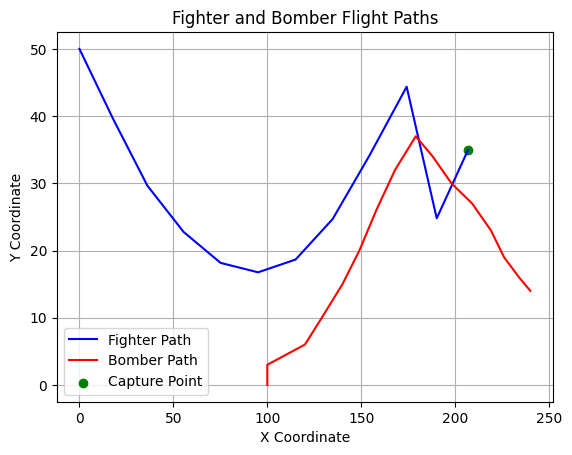

In [11]:
import math
import matplotlib.pyplot as plt

# Fighter coordinates
xf = [0]
yf = [50]
speed = 20  # Fighter speed
capture_distance = 10  # Distance at which the fighter captures the bomber

# Bomber coordinates
xb = [100, 100, 120, 129, 140, 149, 158, 168, 179, 188, 198, 209, 219, 226, 234, 240]
yb = [0, 3, 6, 10, 15, 20, 26, 32, 37, 34, 30, 27, 23, 19, 16, 14]

def calc_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def sin_theta(x1, y1, x2, y2):
    return (y2 - y1) / calc_distance(x1, y1, x2, y2)

def cos_theta(x1, y1, x2, y2):
    return (x2 - x1) / calc_distance(x1, y1, x2, y2)

def simulate_flight():
    global xf, yf, xb, yb, speed, capture_distance
    iteration = 0

    while True:
        xf = xf + [xf[-1] + speed * cos_theta(xf[-1], yf[-1], xb[iteration], yb[iteration])]
        yf = yf + [yf[-1] + speed * sin_theta(xf[-1], yf[-1], xb[iteration], yb[iteration])]

        distance = calc_distance(xf[iteration], yf[iteration], xb[iteration], yb[iteration])
        print("Iteration:", iteration+1, "Distance:", distance)
        iteration += 1
        if distance <= capture_distance or len(xf) >= len(xb):
            break

def plot_flight():
    plt.plot(xf, yf, label='Fighter Path', color='blue')
    plt.plot(xb, yb, label='Bomber Path', color='red')
    plt.scatter(xf[-1], yf[-1], color='green', label='Capture Point')
    plt.title('Fighter and Bomber Flight Paths')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

def plot_fight_animation():
    plt.ion()
    fig, ax = plt.subplots()
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 100)
    fighter_line, = ax.plot([], [], 'b-', label='Fighter Path')
    bomber_line, = ax.plot([], [], 'r-', label='Bomber Path')
    fighter_point, = ax.plot([], [], 'bo', label='Fighter')
    bomber_point, = ax.plot([], [], 'ro', label='Bomber')
    ax.legend()
    ax.grid()

    for i in range(len(xf)):
        fighter_line.set_data(xf[:i+1], yf[:i+1])
        bomber_line.set_data(xb[:i+1], yb[:i+1])
        fighter_point.set_data(xf[:i], yf[:i])
        bomber_point.set_data(xb[:i], yb[:i])
        plt.pause(0.5)

    plt.ioff()
    plt.show()

simulate_flight()
plot_flight()

# Run the animation in a single file for better compatibility
# plot_fight_animation()

### 3D Version

#### 1. The 3D Euclidean Distance

The distance $D$ between the fighter $(x_f, y_f, z_f)$ and the bomber $(x_b, y_b, z_b)$ is now the magnitude of the displacement vector in 3D space:


$$D = \sqrt{(x_b - x_f)^2 + (y_b - y_f)^2 + (z_b - z_f)^2}$$

#### 2. Directional Components (Direction Cosines)

The fighter must decompose its constant speed $V$ into components that point directly toward the target. This is achieved by dividing each displacement component by the total distance $D$:

* **X-component ($V_x$):** $V \cdot \frac{x_b - x_f}{D}$
* **Y-component ($V_y$):** $V \cdot \frac{y_b - y_f}{D}$
* **Z-component ($V_z$):** $V \cdot \frac{z_b - z_f}{D}$

#### 3. State Update Equations

In each iteration, the fighter updates its position by adding the velocity components to its current coordinates:

$$x_{f, \text{new}} = x_{f, \text{old}} + V \cdot \text{cos\_theta}(\text{azimuth component})$$

$$y_{f, \text{new}} = y_{f, \text{old}} + V \cdot \text{sin\_theta}(\text{azimuth component})$$

$$z_{f, \text{new}} = z_{f, \text{old}} + V \cdot \text{sin\_phi}(\text{elevation component})$$

Iteration: 1 Distance: 111.80339887498948
Iteration: 2 Distance: 90.0373063838465
Iteration: 3 Distance: 87.56947209689841
Iteration: 4 Distance: 75.63662428124731
Iteration: 5 Distance: 66.41726456828744
Iteration: 6 Distance: 55.96349153539731
Iteration: 7 Distance: 45.5004092954095
Iteration: 8 Distance: 35.82864253435405
Iteration: 9 Distance: 26.64790269913945
Iteration: 10 Distance: 18.407471214949947
Iteration: 11 Distance: 10.295713805036083
Iteration: 12 Distance: 9.945906440073788


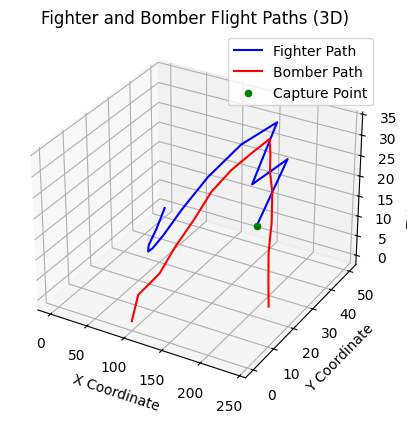

In [12]:
import math
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt

# Fighter coordinates
xf = [0]
yf = [50]
zf = [0]
speed = 20  # Fighter speed
capture_distance = 10  # Distance at which the fighter captures the bomber

# Bomber coordinates
xb = [100, 100, 120, 129, 140, 149, 158, 168, 179, 188, 198, 209, 219, 226, 234, 240]
yb = [0, 3, 6, 10, 15, 20, 26, 32, 37, 34, 30, 27, 23, 19, 16, 14]
zb = [0, 5, 10, 15, 20, 25, 28, 30, 32, 30, 28, 25, 20, 15, 10, 5]

def calc_distance(x1, y1, z1, x2, y2, z2):
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)

def sin_theta(x1, y1, z1, x2, y2, z2):
    return (y2 - y1) / calc_distance(x1, y1, z1, x2, y2, z2)

def cos_theta(x1, y1, z1, x2, y2, z2):
    return (x2 - x1) / calc_distance(x1, y1, z1, x2, y2, z2)

def sin_phi(x1, y1, z1, x2, y2, z2):
    return (z2 - z1) / calc_distance(x1, y1, z1, x2, y2, z2)

def simulate_flight():
    global xf, yf, zf, xb, yb, zb, speed, capture_distance
    iteration = 0

    while True:
        xf = xf + [xf[-1] + speed * cos_theta(xf[-1], yf[-1], zf[-1], xb[iteration], yb[iteration], zb[iteration])]
        yf = yf + [yf[-1] + speed * sin_theta(xf[-1], yf[-1], zf[-1], xb[iteration], yb[iteration], zb[iteration])]
        zf = zf + [zf[-1] + speed * sin_phi(xf[-1], yf[-1], zf[-1], xb[iteration], yb[iteration], zb[iteration])]

        distance = calc_distance(xf[iteration], yf[iteration], zf[iteration], xb[iteration], yb[iteration], zb[iteration])
        print("Iteration:", iteration+1, "Distance:", distance)
        iteration += 1
        if distance <= capture_distance or len(xf) >= len(xb):
            break

def plot_flight():
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xf, yf, zf, label='Fighter Path', color='blue')
    ax.plot(xb, yb, zb, label='Bomber Path', color='red')
    ax.scatter(xf[-1], yf[-1], zf[-1], color='green', label='Capture Point')
    ax.set_title('Fighter and Bomber Flight Paths (3D)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    ax.legend()
    plt.show()

def plot_fight_animation():
    plt.ion()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 100)
    ax.set_zlim(0, 40)
    fighter_line, = ax.plot([], [], [], 'b-', label='Fighter Path')
    bomber_line, = ax.plot([], [], [], 'r-', label='Bomber Path')
    fighter_point, = ax.plot([], [], [], 'bo', label='Fighter')
    bomber_point, = ax.plot([], [], [], 'ro', label='Bomber')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.grid()

    for i in range(len(xf)):
        fighter_line.set_data(xf[:i+1], yf[:i+1])
        fighter_line.set_3d_properties(zf[:i+1])
        bomber_line.set_data(xb[:i+1], yb[:i+1])
        bomber_line.set_3d_properties(zb[:i+1])
        fighter_point.set_data([xf[i]], [yf[i]])
        fighter_point.set_3d_properties([zf[i]])
        bomber_point.set_data([xb[i]], [yb[i]])
        bomber_point.set_3d_properties([zb[i]])
        plt.pause(0.5)

    plt.ioff()
    plt.show()

simulate_flight()
plot_flight()